In [1571]:
import pandas as pd
import seaborn as sns                                                                                     
import matplotlib.pyplot as plt
import numpy as np

In [1572]:
sns.set_theme(style="darkgrid")
sns.set_palette("rocket_r")

In [1573]:
results = pd.read_csv("/Users/ochsneto/Documents/BDMM/BDMM-Flow/results.csv")
results.describe()

,node_count,leaf_count,types_count,process_length,flow_likelihood,flow_duration,bdmm_likelihood,bdmm_duration,num_intervals
count,178206.000000,178206.000000,178206.000000,178206.000000,177248.000000,1.782060e+05,178206.000000,1.782060e+05,178206.000000
mean,120.250328,60.625164,5.989462,2.994274,-427.398487,1.021946e+06,-431.232938,2.996009e+06,2.481768
std,1152.300787,576.150393,2.571301,1.145696,5473.411841,2.461780e+06,5479.222632,1.421733e+07,1.499893
min,3.000000,2.000000,2.000000,1.000035,-628331.480857,1.445900e+04,-629888.370022,2.695800e+04,1.000000
25%,5.000000,3.000000,4.000000,2.010414,-89.575664,1.384160e+05,-91.531613,1.620420e+05,1.000000
50%,11.000000,6.000000,6.000000,2.989594,-20.121164,3.500420e+05,-20.827235,4.079590e+05,1.000000
75%,41.000000,21.000000,8.000000,3.978882,-8.192309,9.983330e+05,-8.544844,1.378875e+06,4.000000
max,122783.000000,61392.000000,10.000000,4.999880,0.412177,2.532962e+08,-0.230552,9.685411e+08,4.000000


In [1574]:
results = results[results["leaf_count"] > 10]
results["speedup"] = results["bdmm_duration"] / results["flow_duration"]
results["binned_leaves"] = results["leaf_count"].apply(lambda x: x // 200 * 200)
results["error"] = np.abs(np.exp(results["bdmm_likelihood"]) - np.exp(results["flow_likelihood"])) / np.exp(results["bdmm_likelihood"])

In [1575]:
normal_identity = results[~results["use_inverse_flow"] & (results["initial_state_strategy"] == "identity") & ~results["use_splitting"]]
normal_random = results[~results["use_inverse_flow"] & (results["initial_state_strategy"] == "random") & ~results["use_splitting"]]
inverse_identity = results[results["use_inverse_flow"] & (results["initial_state_strategy"] == "identity") & ~results["use_splitting"]]
inverse_random = results[results["use_inverse_flow"] & (results["initial_state_strategy"] == "random") & ~results["use_splitting"]]
splitting_identity = results[results["use_splitting"] & (results["initial_state_strategy"] == "identity")]
splitting_random = results[results["use_splitting"] & (results["initial_state_strategy"] == "random")]

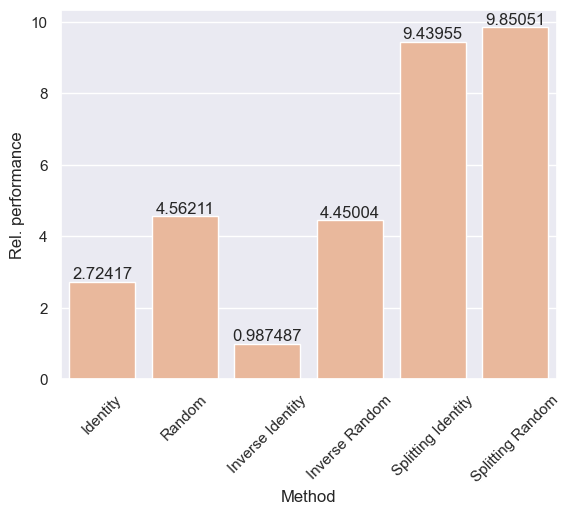

In [1576]:
ax = sns.barplot(data=pd.DataFrame({
    "Method": [
        "Identity", 
        "Random", 
        "Inverse Identity",
        "Inverse Random",
        "Splitting Identity",
        "Splitting Random",
    ],
    "Rel. performance": [
        normal_identity["speedup"].median(),
        normal_random["speedup"].median(),
        inverse_identity["speedup"].median(),
        inverse_random["speedup"].median(),
        splitting_identity["speedup"].median(),
        splitting_random["speedup"].median(),
    ]
}), x="Method", y="Rel. performance", errorbar="pi")
plt.xticks(rotation=45)
for i in ax.containers:
    ax.bar_label(i,)

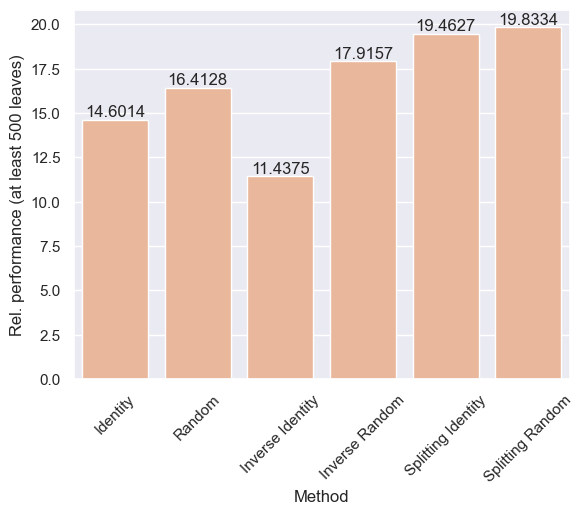

In [1577]:
ax = sns.barplot(data=pd.DataFrame({
    "Method": [
        "Identity", 
        "Random", 
        "Inverse Identity",
        "Inverse Random",
        "Splitting Identity",
        "Splitting Random",
    ],
    "Rel. performance (at least 500 leaves)": [
        normal_identity[normal_identity["leaf_count"] > 500]["speedup"].median(),
        normal_random[normal_random["leaf_count"] > 500]["speedup"].median(),
        inverse_identity[inverse_identity["leaf_count"] > 500]["speedup"].median(),
        inverse_random[inverse_random["leaf_count"] > 500]["speedup"].median(),
        splitting_identity[splitting_identity["leaf_count"] > 500]["speedup"].median(),
        splitting_random[splitting_random["leaf_count"] > 500]["speedup"].median(),
    ]
}), x="Method", y="Rel. performance (at least 500 leaves)")

plt.xticks(rotation=45)

for i in ax.containers:
    ax.bar_label(i,)

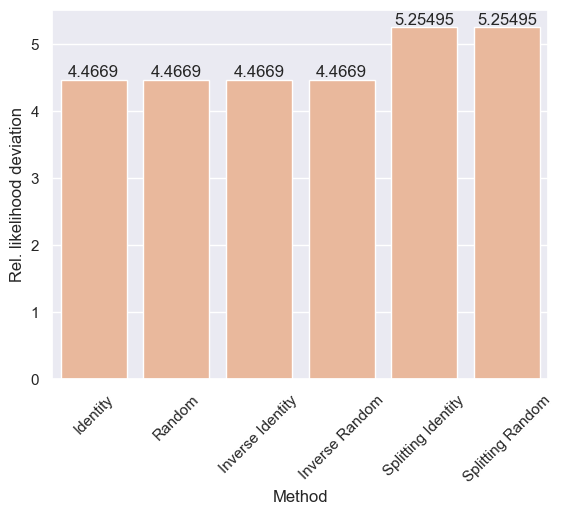

In [1578]:
ax = sns.barplot(data=pd.DataFrame({
    "Method": [
        "Identity", 
        "Random", 
        "Inverse Identity",
        "Inverse Random",
        "Splitting Identity",
        "Splitting Random",
    ],
    "Rel. likelihood deviation": [
        normal_identity["error"].median(),
        normal_random["error"].median(),
        inverse_identity["error"].median(), 
        inverse_random["error"].median(), 
        splitting_identity["error"].median(), 
        splitting_random["error"].median(), 
    ]
}), x="Method", y="Rel. likelihood deviation")

plt.xticks(rotation=45)

for i in ax.containers:
    ax.bar_label(i,)

Text(0, 0.5, 'BDMM Log Likelihood')

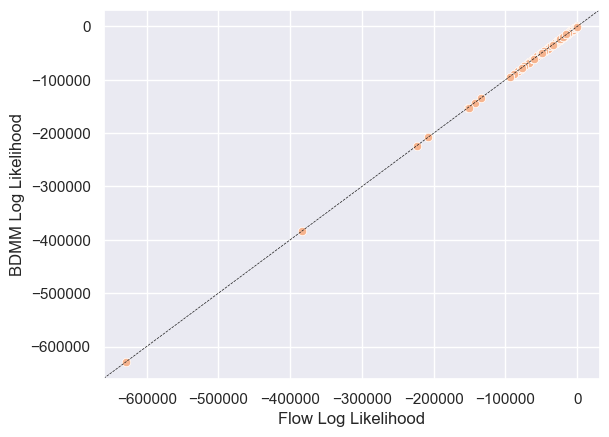

In [1579]:
ax = sns.scatterplot(results, x="flow_likelihood", y="bdmm_likelihood")
ax.plot(ax.get_xlim(), ax.get_xlim(), linestyle='--', color='k', lw=0.5, scalex=False, scaley=False)

plt.xlabel('Flow Log Likelihood')
plt.ylabel('BDMM Log Likelihood')

In [1580]:
correlation = results[["flow_likelihood", "bdmm_likelihood"]].corr()
correlation

,flow_likelihood,bdmm_likelihood
flow_likelihood,1.000000,0.999998
bdmm_likelihood,0.999998,1.000000
